bordes

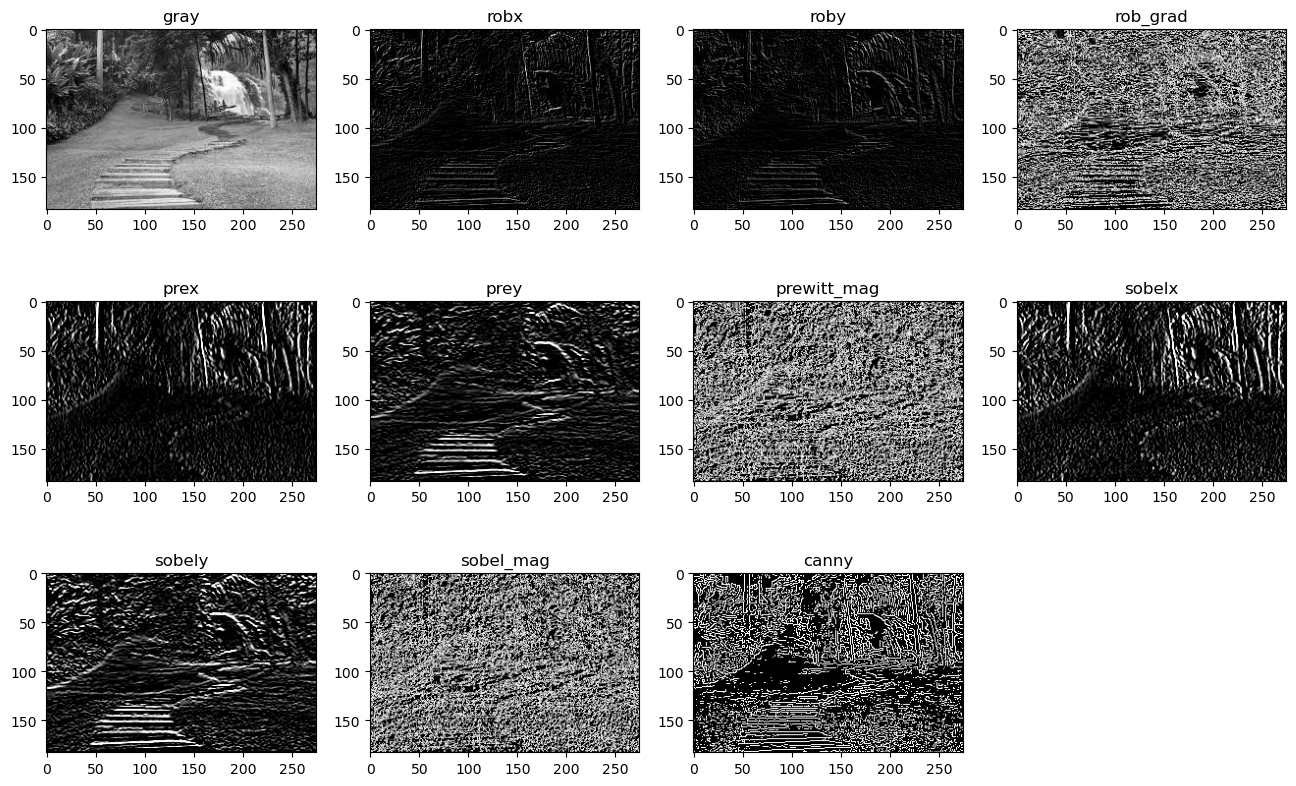

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img=cv2.imread('images.jpg')
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
robertx=np.array([[-1,0], [0,1]])
roberty=np.array([[0,-1], [1,0]])
robx_img=cv2.filter2D(gray,-1,robertx)
roby_img=cv2.filter2D(gray,-1,roberty)
rob_grad= np.sqrt(robx_img ** 2+roby_img ** 2)
rob_grad_dir=np.arctan2(roby_img,robx_img)

#prewit

prewitt_x=np.array([[-1,0,1], [-1,0,1], [-1,0,1]])
prewitt_y=np.array([[-1,-1,-1], [0,0,0], [1,1,1]])
prex_img=cv2.filter2D(gray,-1,prewitt_x)
prey_img=cv2.filter2D(gray,-1,prewitt_y)
prewitt_mag=np.sqrt(prex_img ** 2+prey_img ** 2)
preww_dir=np.arctan2(prewitt_mag,prewitt_mag)


# solbel

sobel_x=np.array([[-1,0,1], [-2,0,2], [-1,0,1]])
sobel_y=np.array([[-1,-2,-1], [0,0,0], [1,2,1]])
sobelx_img=cv2.filter2D(gray,-1,sobel_x)
sobely_img=cv2.filter2D(gray,-1,sobel_y)
sobel_mag=np.sqrt(sobelx_img ** 2+sobely_img ** 2)
sobel_dir=np.arctan2(sobely_img,sobelx_img)

cany_img=cv2.Canny(gray,100,100)

plt.figure(figsize=(16,10))

plt.subplot(3,4,1)
plt.imshow(gray,cmap='gray')
plt.title('gray')

plt.subplot(3,4,2)
plt.imshow(robx_img,cmap='gray')
plt.title('robx')

plt.subplot(3,4,3)
plt.imshow(roby_img,cmap='gray')
plt.title('roby')

plt.subplot(3,4,4)
plt.imshow(rob_grad,cmap='gray')
plt.title('rob_grad')

plt.subplot(3,4,5)
plt.imshow(prex_img,cmap='gray')
plt.title('prex')

plt.subplot(3,4,6)
plt.imshow(prey_img,cmap='gray')
plt.title('prey')

plt.subplot(3,4,7)
plt.imshow(prewitt_mag,cmap='gray')
plt.title('prewitt_mag')

plt.subplot(3,4,8)
plt.imshow(sobelx_img,cmap='gray')
plt.title('sobelx')

plt.subplot(3,4,9)
plt.imshow(sobely_img,cmap='gray')
plt.title('sobely')

plt.subplot(3,4,10)
plt.imshow(sobel_mag,cmap='gray')
plt.title('sobel_mag')

plt.subplot(3,4,11)
plt.imshow(cany_img,cmap='gray')
plt.title('canny')

plt.show()

sobel

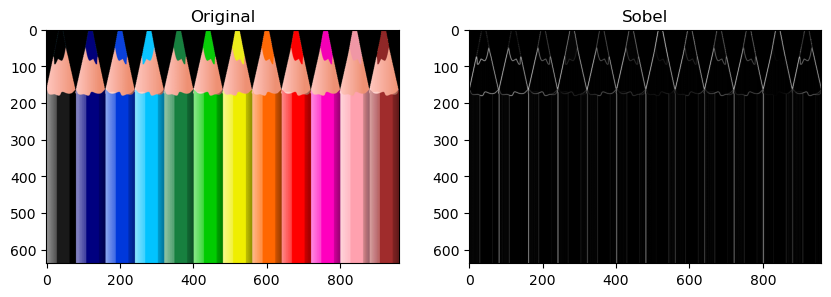

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel(img):
    img_gris=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    g_x=cv2.Sobel(img_gris,cv2.CV_64F,1,0,ksize=3)
    g_y=cv2.Sobel(img_gris,cv2.CV_64F,0,1,ksize=3)

    mag=np.sqrt(np.square(g_x)+np.square(g_y))
    mag=cv2.normalize(mag,None,0,255,cv2.NORM_MINMAX,cv2.CV_8U)
    return mag


img=cv2.imread('colores.jpg')

resultado=filtro_sobel(img)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(resultado,cmap='gray')
plt.title('Sobel')

plt.show()


sobel mejorado

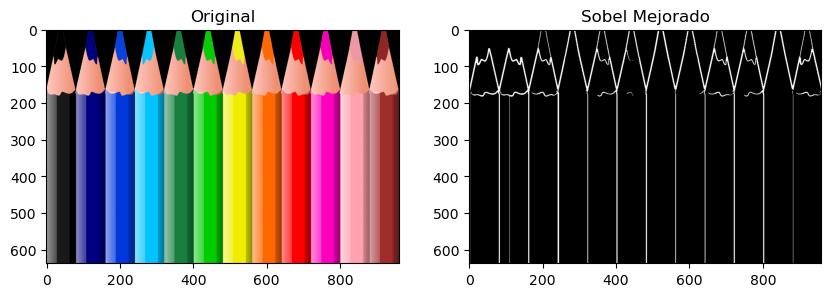

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel_mejorado(img,kernel_size,umbral):
    img_gris=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    #para mejorar la deteccion filro gauss
    img_gris=cv2.GaussianBlur(img_gris,(3,3),0)

    g_x=cv2.Sobel(img_gris,cv2.CV_64F,1,0,ksize=kernel_size)
    g_y=cv2.Sobel(img_gris,cv2.CV_64F,0,1,ksize=kernel_size)

    #mag=np.sqrt(np.square(g_x)+np.square(g_y))
    mag=np.sqrt(g_x ** 2+g_y ** 2)
    mag=cv2.normalize(mag,None,0,255,cv2.NORM_MINMAX,cv2.CV_8U)
    _,bordes=cv2. threshold(mag, umbral, 255, cv2. THRESH_BINARY+cv2.THRESH_OTSU)
    #OPERACION MORPH UNIR BORDES ROTOS
    kernel_m=np.ones((2,2),np.uint8)
    bordes=cv2.morphologyEx(bordes,cv2.MORPH_CLOSE,kernel_m)
    return bordes


img=cv2.imread('colores.jpg')

resultado=filtro_sobel_mejorado(img,5,40)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(resultado,cmap='gray')
plt.title('Sobel Mejorado')

plt.show()    

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_roberts_mejorado(img):
    img_gris=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    suavizar=cv2.GaussianBlur(img_gris,(3,3),0)
    robertx=np.array([[2,0],[0,-2]]),dtype=np.float32)
    roberty=np.array([[0,2],[-2,0]]),dtype=np.float32)
    r_x=cv2.filter2D(suavizar,-1,robertx)
    r_y=cv2.filter2D(suavizar,-1,roberty)
    roberts=cv2.addWeighted(np.abs(r_x),0.7,np.abs(r_y),0.7,0)
    _,bordes=cv2.threshold(roberts,50,255,cv2.THRESH_BINARY)
    return bordes


Roberts

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_roberts(img):
    img_gris=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    robertx=np.array([[-1,0], [0,1]],dtype=np.float32)
    roberty=np.array([[0,-1], [1,0]],dtype=np.float32)
    r_x=cv2.filter2D(img_gris,-1, robertx)
    r_y=cv2.filter2D(img_gris,-1, roberty)
    roberts=cv2.addWeighted(r_x,0.5,r_y,0.5,0)
    return roberts


img=cv2.imread('colores2.jpg')

resultado=filtro_roberts(img)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(resultado,cmap='gray')
plt.title('Roberts')

plt.show()


Robert mejorado

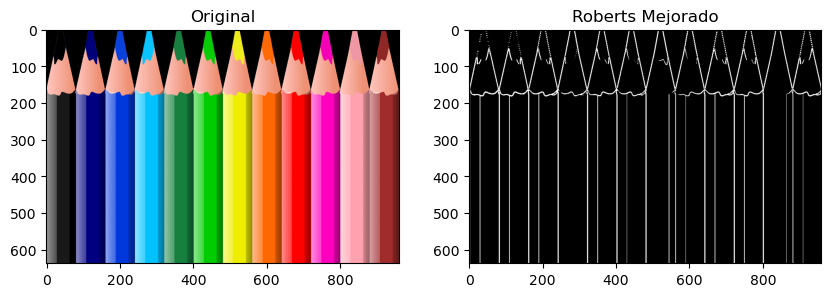

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_roberts_mejorado(img):
    img_gris=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    suavizar=cv2.GaussianBlur(img_gris,(3,3),0)
    robertx=np.array([[2,0],[0,-2]],dtype=np.float32)
    roberty=np.array([[0,2],[-2,0]],dtype=np.float32)
    r_x=cv2.filter2D(suavizar,-1,robertx)
    r_y=cv2.filter2D(suavizar,-1,roberty)
    roberts=cv2.addWeighted(np.abs(r_x),0.7,np.abs(r_y),0.7,0)
    _,bordes=cv2.threshold(roberts,20,255,cv2. THRESH_BINARY)
    return bordes


img=cv2.imread('colores.jpg')

resultado=filtro_roberts_mejorado(img)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(resultado,cmap='gray')
plt.title('Roberts Mejorado')

plt.show()


previtt mejorado

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_prewitt_mejorado(img):
    img_gris=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    suavizar=cv2.GaussianBlur(img_gris,(3,3),0)

    kernelx=np.array([[-3,0,3],[-3,0,3],[-3,0,3]],dtype=np.float32)
    kernely=np.array([[3,3,3],[0,0,0],[-3,-3,-3]],dtype=np.float32)

    grad_x=cv2.filter2D(suavizar,cv2.CV_64F,kernelx)
    grad_y=cv2.filter2D(suavizar,cv2.CV_64F,kernely)
    
    magnitud=np.sqrt(grad_x**2+grad_y**2)
    _,bordes=cv2.threshold(magnitud,20,255,cv2. THRESH_BINARY)
    return bordes


img=cv2.imread('BMW 635.jpg.jpeg')

resultado=filtro_prewitt_mejorado(img)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(resultado,cmap='gray')
plt.title('Prewitt Mejorado')

plt.show()


filtro canny

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_canny(img,umbral_bajo=100,umbral_alto=200):
    img_gris=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    canny=cv2.Canny(img_gris,umbral_bajo,umbral_alto)
    return canny

img=cv2.imread('BMW 635.jpg.jpeg')

resultado=filtro_canny(img)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(resultado,cmap='gray')
plt.title('Canny')

plt.show()    